In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
df=pd.read_csv(r"C:\Users\hi\Downloads\archive (5)\PS_20174392719_1491204439457_log.csv")

In [31]:
df.head(50)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.0,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.0,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.0,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.0,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.0,0.00,0,0
5,1,PAYMENT,7817.71,C90045638,53860.00,46042.29,M573487274,0.0,0.00,0,0
6,1,PAYMENT,7107.77,C154988899,183195.00,176087.23,M408069119,0.0,0.00,0,0
7,1,PAYMENT,7861.64,C1912850431,176087.23,168225.59,M633326333,0.0,0.00,0,0
8,1,PAYMENT,4024.36,C1265012928,2671.00,0.00,M1176932104,0.0,0.00,0,0
9,1,DEBIT,5337.77,C712410124,41720.00,36382.23,C195600860,41898.0,40348.79,0,0


In [19]:
print("Ingesting financial transaction ledger data...")
# Load the first 500,000 rows to keep training fast and clean
df_kra = pd.read_csv(r"C:\Users\hi\Downloads\archive (5)\PS_20174392719_1491204439457_log.csv", nrows=500000)
print(f" Dataset successfully parsed. Total transactions loaded: {len(df_kra)}")
print(f" Available fields: {df_kra.columns.tolist()}")


Ingesting financial transaction ledger data...
 Dataset successfully parsed. Total transactions loaded: 500000
 Available fields: ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']


In [21]:
print("\n Engineering transaction compliance features...")

# 1. One-hot encode the transaction types (CASH_OUT, TRANSFER, etc.)
df_kra = pd.get_dummies(df_kra, columns=['type'], drop_first=True)

# 2. Extract tax variance risk metrics (e.g., discrepancies in sender/receiver accounts)
df_kra['sender_balance_error'] = df_kra['newbalanceOrig'] + df_kra['amount'] - df_kra['oldbalanceOrg']
df_kra['receiver_balance_error'] = df_kra['oldbalanceDest'] + df_kra['amount'] - df_kra['newbalanceDest']

# 3. Create a high-value transaction risk flag
df_kra['is_high_value'] = (df_kra['amount'] > 150000).astype(int) # Over KES 150k limit

# Drop string account identifiers that machine learning models cannot read
drop_cols = ['nameOrig', 'nameDest', 'isFlaggedFraud']
X_kra = df_kra.drop(columns=drop_cols + ['isFraud'])
y_kra = df_kra['isFraud'] # This maps to our non-compliant/fraud anomaly target

print("Feature matrix finalized.")



 Engineering transaction compliance features...
Feature matrix finalized.


In [27]:
print("\nTraining KRA Compliance Anomaly Model...")

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X_kra, y_kra, test_size=0.2, random_state=42, stratify=y_kra)

# Initialize the classifier
kra_model = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
kra_model.fit(X_train, y_train)

# Run classification inference
y_pred = kra_model.predict(X_test)
print("Training complete!")



Training KRA Compliance Anomaly Model...
Training complete!



 --- KRA Compliance Audit Performance ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     99953
           1       1.00      0.87      0.93        47

    accuracy                           1.00    100000
   macro avg       1.00      0.94      0.97    100000
weighted avg       1.00      1.00      1.00    100000



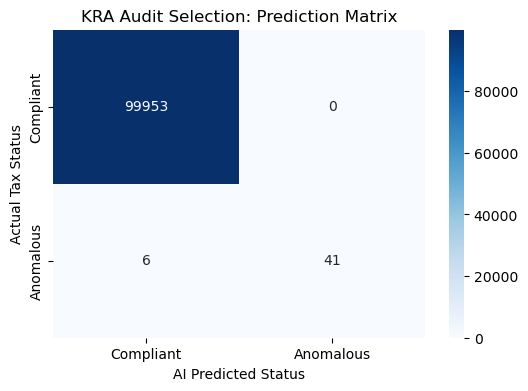

In [28]:
print("\n --- KRA Compliance Audit Performance ---")
print(classification_report(y_test, y_pred))

# Plot a heatmap of the Auditing Outcomes
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Compliant', 'Anomalous'], yticklabels=['Compliant', 'Anomalous'])
plt.title('KRA Audit Selection: Prediction Matrix')
plt.ylabel('Actual Tax Status')
plt.xlabel('AI Predicted Status')
plt.show()
